## Step 0: Mount Google Drive
This cell establishes a connection to Google Drive to access the **Week 2 Standardized Features** we extracted in the previous notebook. We define the `PROJECT_ROOT` to maintain consistent path references across the team's shared directory.

In [1]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define the project root directory
PROJECT_ROOT = '/content/drive/MyDrive/ML2-Team2/Final Project/face-to-bmi'

if os.path.exists(PROJECT_ROOT):
    print(f"✅ Project folder linked: {PROJECT_ROOT}")
else:
    print(f"❌ Project folder NOT found. Please verify the path.")

Mounted at /content/drive
✅ Project folder linked: /content/drive/MyDrive/ML2-Team2/Final Project/face-to-bmi


## Cell 1: Environment Setup and Week 2 Data Loading
We initialize our analysis environment with `numpy`, `pandas`, and visualization libraries. In this cell, we load the **v2_fc6** feature sets (Standardized version) and their corresponding labels.

The primary goal here is to verify that our data shapes align with our cleaned dataset:
* **Training Set**: $3210 \times 4096$
* **Testing Set**: $752 \times 4096$

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Path Definitions ---
# Pointing to our Week 2 experiments folder
W2_EXP_DIR = os.path.join(PROJECT_ROOT, "models/ryan/week2_experiments")

print("📂 Loading Week 2 extracted features...")

# Load Training Data
train_features = np.load(os.path.join(W2_EXP_DIR, 'train_features_v2_fc6.npy'))
train_bmis = np.load(os.path.join(W2_EXP_DIR, 'train_bmis_v2.npy'))
train_filenames = np.load(os.path.join(W2_EXP_DIR, 'train_filenames_v2.npy'))

# Load Testing Data
test_features = np.load(os.path.join(W2_EXP_DIR, 'test_features_v2_fc6.npy'))
test_bmis = np.load(os.path.join(W2_EXP_DIR, 'test_bmis_v2.npy'))
test_filenames = np.load(os.path.join(W2_EXP_DIR, 'test_filenames_v2.npy'))

# --- Shape Verification ---
print("\n--- 📏 Shape Verification ---")
print(f"Train Features: {train_features.shape} | Labels: {train_bmis.shape}")
print(f"Test Features:  {test_features.shape}  | Labels: {test_bmis.shape}")

if train_features.shape[0] + test_features.shape[0] == 3962:
    print("✅ Total sample count (3,962) matches Role 2's standardized report.")
else:
    print("⚠️ Sample count mismatch. Please check the 'clean_data.csv' logic.")

📂 Loading Week 2 extracted features...

--- 📏 Shape Verification ---
Train Features: (3210, 4096) | Labels: (3210,)
Test Features:  (752, 4096)  | Labels: (752,)
✅ Total sample count (3,962) matches Role 2's standardized report.


## Cell 2: Numerical Profiling & Sparsity Analysis
Before performing dimensionality reduction, we must understand the "health" of our features. Since VGG-Face uses the **$ReLU$** activation function, we expect a high degree of **sparsity** (many zeros).

We also examine the distribution of non-zero values to determine if the features require scaling before being passed to Role 4's SVR or XGBoost models.

📊 Analyzing Feature Statistics...
--- Statistics Report ---
Sparsity (Percentage of 0s): 66.08%
Mean Value:  0.3427
Std Dev:     0.6664
Range:       [0.0000, 10.0684]


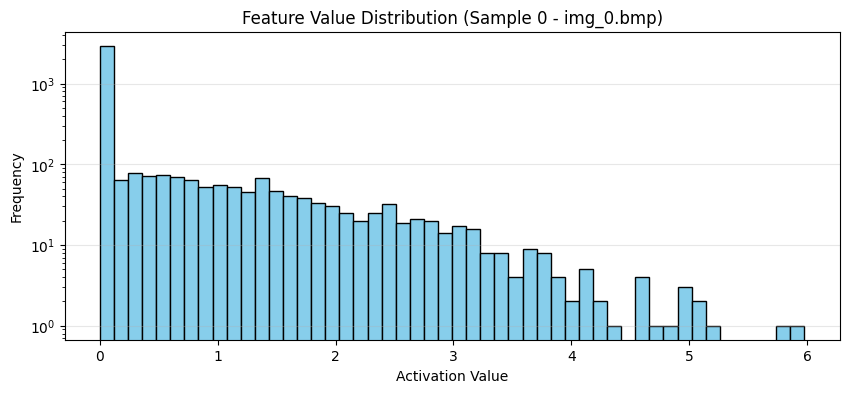


💡 PM Insight: If sparsity is > 70%, the model is highly selective.
If the Max Value is very high (e.g., > 10), Role 4 might need to use a RobustScaler.


In [3]:
# Cell 2: Numerical Profiling

print("📊 Analyzing Feature Statistics...")

# 1. Sparsity Check
# Count total zeros in the training matrix
total_elements = train_features.size
zero_elements = total_elements - np.count_nonzero(train_features)
sparsity = (zero_elements / total_elements) * 100

# 2. Basic Stats
mean_val = np.mean(train_features)
std_val = np.std(train_features)
max_val = np.max(train_features)
min_val = np.min(train_features)

print(f"--- Statistics Report ---")
print(f"Sparsity (Percentage of 0s): {sparsity:.2f}%")
print(f"Mean Value:  {mean_val:.4f}")
print(f"Std Dev:     {std_val:.4f}")
print(f"Range:       [{min_val:.4f}, {max_val:.4f}]")

# 3. Visualization: Histogram of a single sample's features
# This helps us see the distribution of intensities for one face.
sample_idx = 0
plt.figure(figsize=(10, 4))
plt.hist(train_features[sample_idx], bins=50, color='skyblue', edgecolor='black')
plt.title(f"Feature Value Distribution (Sample 0 - {train_filenames[sample_idx]})")
plt.xlabel("Activation Value")
plt.ylabel("Frequency")
plt.yscale('log') # Use log scale to see small non-zero values more clearly
plt.grid(axis='y', alpha=0.3)
plt.show()

print("\n💡 PM Insight: If sparsity is > 70%, the model is highly selective.")
print("If the Max Value is very high (e.g., > 10), Role 4 might need to use a RobustScaler.")

## Cell 2.5: Scaling Strategy Factory
This cell implements a modular scaling pipeline. Given the current data profile—**66.08% sparsity** and a range of **[0, 10.06]**—the choice of scaling is critical for both visualization and model convergence.

We provide four strategies:
1. **`none`**: Uses raw VGG-Face activations.
2. **`standard`**: Transforms features to have a mean of 0 and variance of 1. (Note: This breaks sparsity).
3. **`maxabs`**: Scales each feature by its maximum absolute value, mapping data to **[0, 1]** while **preserving the 66.08% sparsity**.
4. **`robust`**: Uses the interquartile range (IQR) to reduce the influence of extreme values (like our max of 10.06).

**Recommendation**: For Deep Learning backbones and sparse features, **`maxabs`** is often the preferred starting point as it stabilizes gradients without losing the semantic meaning of "zero" (inactive neurons).

In [4]:
# Cell 2.5: Scaling Strategy Factory
from sklearn.preprocessing import StandardScaler, MaxAbsScaler, RobustScaler

# --- CONFIGURATION: Choose your strategy ---
# Options: 'none', 'standard', 'maxabs', 'robust'
SCALING_STRATEGY = 'maxabs'

def apply_scaling(features, strategy):
    if strategy == 'none':
        print("💡 Strategy: Using Raw Features (None)")
        return features, None

    elif strategy == 'standard':
        print("💡 Strategy: StandardScaler (Mean=0, Var=1)")
        scaler = StandardScaler()

    elif strategy == 'maxabs':
        print("💡 Strategy: MaxAbsScaler (Range [0, 1], Preserves Sparsity)")
        scaler = MaxAbsScaler()

    elif strategy == 'robust':
        print("💡 Strategy: RobustScaler (IQR-based scaling)")
        scaler = RobustScaler()

    else:
        raise ValueError("Unknown strategy. Choose 'none', 'standard', 'maxabs', or 'robust'.")

    # Fit on training data and transform
    scaled_data = scaler.fit_transform(features)
    return scaled_data, scaler

# Apply the chosen strategy to training data
X_train_scaled, current_scaler = apply_scaling(train_features, SCALING_STRATEGY)

# Apply the SAME scaler to test data (to prevent data leakage)
if current_scaler:
    X_test_scaled = current_scaler.transform(test_features)
else:
    X_test_scaled = test_features

print(f"✅ Scaling completed. Current Matrix Shape: {X_train_scaled.shape}")

💡 Strategy: MaxAbsScaler (Range [0, 1], Preserves Sparsity)
✅ Scaling completed. Current Matrix Shape: (3210, 4096)


## Cell 3: PCA and Explained Variance Analysis
We apply **Principal Component Analysis (PCA)** to evaluate the information density of the 4096-dimensional feature space. By analyzing the **Cumulative Explained Variance**, we determine how much compression is feasible without losing significant predictive signals.

Based on the preliminary run, we observe that the top 500 components capture approximately **85.71%** of the total variance, indicating a rich and non-redundant feature representation.

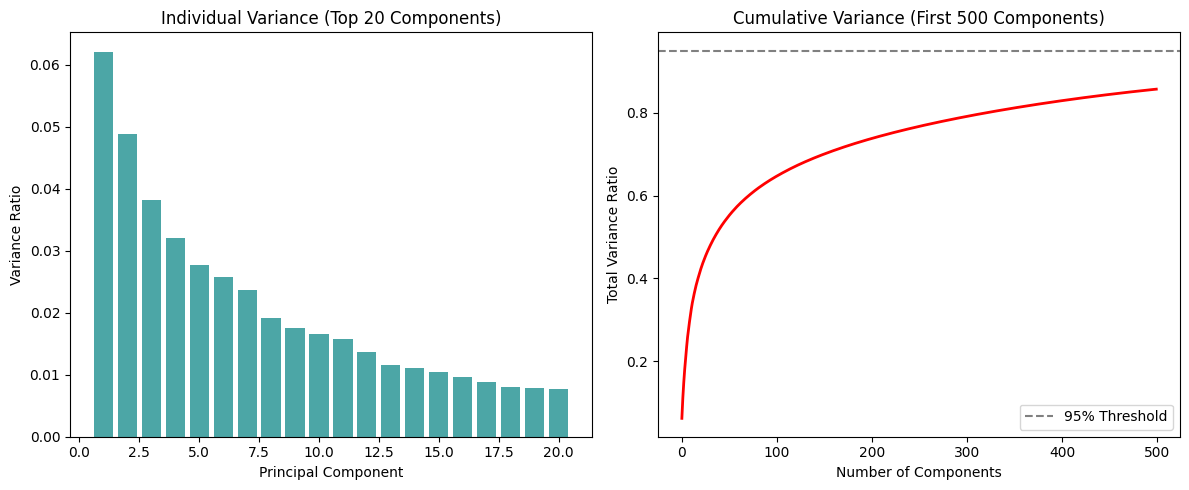

--- PCA Quantitative Report ---
⚠️ 95% variance not reached within 500 components.
Current total variance explained: 85.71%
Top 5 components capture: 20.90% of total information.


In [10]:
# Cell 3: PCA Analysis (Stable Version)
from sklearn.decomposition import PCA

# Initialize PCA - capturing the first 500 components for high-dimensional analysis
n_comp = min(500, X_train_scaled.shape[0])
pca = PCA(n_components=n_comp)
pca.fit(X_train_scaled)

# Calculate cumulative explained variance ratio
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# --- Visualization ---
plt.figure(figsize=(12, 5))

# Plot 1: Individual Variance (Scree Plot)
plt.subplot(1, 2, 1)
plt.bar(range(1, 21), pca.explained_variance_ratio_[:20], alpha=0.7, color='teal')
plt.title("Individual Variance (Top 20 Components)")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")

# Plot 2: Cumulative Explained Variance
plt.subplot(1, 2, 2)
plt.plot(cumulative_variance, color='red', linewidth=2)
plt.axhline(y=0.95, color='gray', linestyle='--', label='95% Threshold')
plt.title(f"Cumulative Variance (First {n_comp} Components)")
plt.xlabel("Number of Components")
plt.ylabel("Total Variance Ratio")
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

# --- Quantitative Report ---
print(f"--- PCA Quantitative Report ---")
# Check where cumulative variance hits the 95% mark
reaching_95 = np.where(cumulative_variance >= 0.95)[0]

if len(reaching_95) > 0:
    n95 = reaching_95[0] + 1
    print(f"✅ Components needed for 95% variance: {n95}")
else:
    current_max = cumulative_variance[-1] * 100
    print(f"⚠️ 95% variance not reached within {n_comp} components.")
    print(f"Current total variance explained: {current_max:.2f}%")

# Report the contribution of the most dominant features
top5_sum = np.sum(pca.explained_variance_ratio_[:5]) * 100
print(f"Top 5 components capture: {top5_sum:.2f}% of total information.")

## Cell 3.1: PCA for 95% Explained Variance
In this cell, we adjust the PCA threshold to capture **95%** of the total variance. This high-fidelity compression ensures that we retain most of the predictive signals from the VGG-Face activations while filtering out low-variance noise.

The resulting components will serve as an optimized feature set for non-DL models like SVR, while the original 4096D features remain available for deep learning experiments.

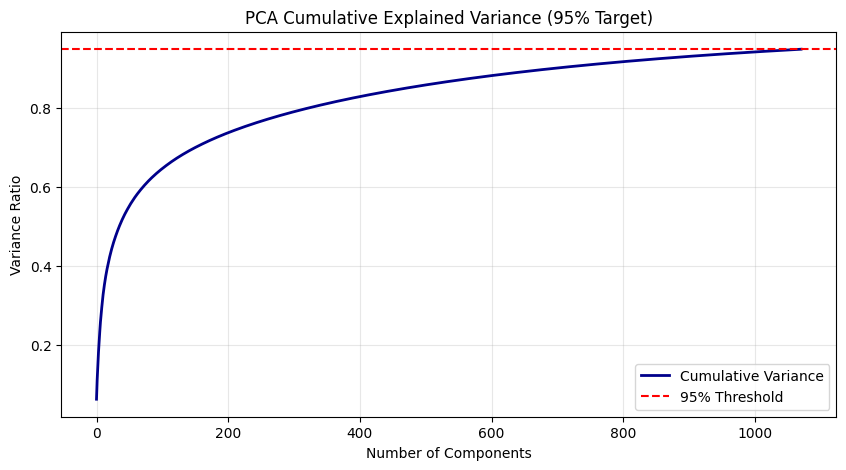

--- PCA 95% Report ---
✅ Dimensions reduced from 4096 to: 1071
Compression Ratio: 3.82x


In [11]:
# Cell 3: PCA Analysis (95% Variance Threshold)
from sklearn.decomposition import PCA

# Initialize PCA to capture 95% of the variance
# We use a float value for n_components to let sklearn find the optimal number of components
pca_95 = PCA(n_components=0.95, svd_solver='full')
X_train_pca = pca_95.fit_transform(X_train_scaled)

# Apply the same PCA transformation to the test set
X_test_pca = pca_95.transform(X_test_scaled)

# --- Visualization: Variance Curve ---
cumulative_variance = np.cumsum(pca_95.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance, color='darkblue', linewidth=2, label='Cumulative Variance')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% Threshold')
plt.title("PCA Cumulative Explained Variance (95% Target)")
plt.xlabel("Number of Components")
plt.ylabel("Variance Ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Quantitative Report ---
n_components_95 = pca_95.n_components_
print(f"--- PCA 95% Report ---")
print(f"✅ Dimensions reduced from 4096 to: {n_components_95}")
print(f"Compression Ratio: {4096 / n_components_95:.2f}x")

## Cell 3.5: Saving PCA-Reduced Features
We serialize the PCA-transformed features into `.npy` files. These files are specifically prepared for **Role 4 (Optimization Expert)** to facilitate baseline training with SVR and other machine learning algorithms that benefit from reduced dimensionality.

In [12]:
# Cell 3.5: Saving PCA Features
PCA_OUTPUT_PATH = os.path.join(W2_EXP_DIR, "pca_reduced")
os.makedirs(PCA_OUTPUT_PATH, exist_ok=True)

print(f"💾 Saving PCA-95 features to: {PCA_OUTPUT_PATH}")

# Save the transformed features
np.save(os.path.join(PCA_OUTPUT_PATH, 'train_features_v2_pca95.npy'), X_train_pca)
np.save(os.path.join(PCA_OUTPUT_PATH, 'test_features_v2_pca95.npy'), X_test_pca)

# Save the PCA model itself (useful for projecting new single images later)
import joblib
joblib.dump(pca_95, os.path.join(PCA_OUTPUT_PATH, 'pca_95_model.pkl'))

print("✅ PCA feature export completed.")

💾 Saving PCA-95 features to: /content/drive/MyDrive/ML2-Team2/Final Project/face-to-bmi/models/ryan/week2_experiments/pca_reduced
✅ PCA feature export completed.


## Cell 4: t-SNE Visualization (1071D PCA-Reduced)
In this cell, we apply **t-Distributed Stochastic Neighbor Embedding (t-SNE)** to the PCA-reduced features (1071 dimensions). By visualizing both the training and testing sets together, we can observe whether the BMI clusters are consistent across different data splits.

We use the `magma` colormap to represent BMI values and different markers to distinguish between the training set (circles) and the testing set (crosses).

🚀 Running t-SNE on 1071D features (N=3962)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


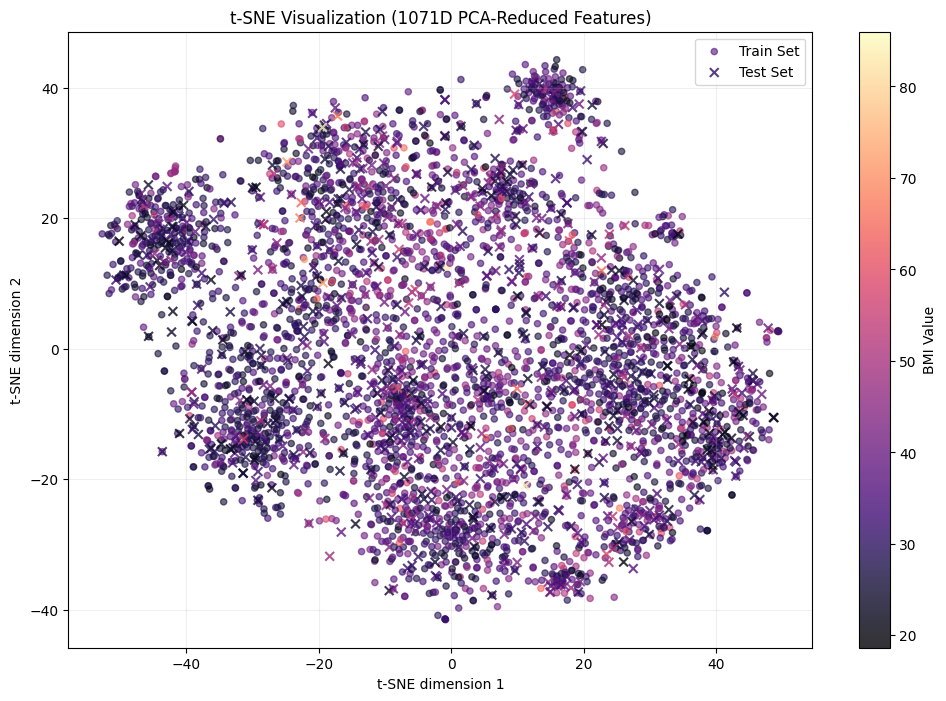

✅ t-SNE (1071D) completion successful.


In [19]:
# Cell 4: t-SNE (1071D Version)
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. Prepare combined data for visualization
# X_train_pca (3210, 1071), X_test_pca (752, 1071)
X_combined_pca = np.vstack([X_train_pca, X_test_pca])
y_combined_bmi = np.concatenate([train_bmis, test_bmis])

# Create labels to distinguish Train (0) and Test (1)
split_labels = np.array([0] * len(train_bmis) + [1] * len(test_bmis))

print(f"🚀 Running t-SNE on 1071D features (N={len(X_combined_pca)})...")

# 2. Initialize and Fit t-SNE
tsne_1071 = TSNE(
    n_components=2,
    perplexity=50, #30, 40, 50, 70
    learning_rate='auto',
    metric='cosine',
    init='random',
    random_state=42,
    early_exaggeration=20,
    n_jobs=-1, # Use all available cores
    n_iter=2000,
    min_grad_norm=1e-7
)

X_tsne_1071 = tsne_1071.fit_transform(X_combined_pca)

# 3. Visualization
plt.figure(figsize=(12, 8))

# Scatter plot for Training Set
plt.scatter(
    X_tsne_1071[split_labels == 0, 0],
    X_tsne_1071[split_labels == 0, 1],
    c=y_combined_bmi[split_labels == 0],
    cmap='magma',
    marker='o',
    alpha=0.6,
    label='Train Set',
    s=20
)

# Scatter plot for Testing Set
plt.scatter(
    X_tsne_1071[split_labels == 1, 0],
    X_tsne_1071[split_labels == 1, 1],
    c=y_combined_bmi[split_labels == 1],
    cmap='magma',
    marker='x',
    alpha=0.8,
    label='Test Set',
    s=40
)

plt.colorbar(label='BMI Value')
plt.title("t-SNE Visualization (1071D PCA-Reduced Features)")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print("✅ t-SNE (1071D) completion successful.")

## Cell 5: UMAP Visualization (1071D PCA-Reduced)
In this cell, we implement **Uniform Manifold Approximation and Projection (UMAP)**. Unlike t-SNE, UMAP is designed to preserve both the local and global topological structure of the data.

We project the 1071-dimensional PCA features into a 2D space to see if the **BMI values** form a continuous gradient. This visualization is a key piece of evidence for **Role 3** to verify that the VGG-Face features successfully encode physical body attributes.

🚀 Running UMAP on 1071D features (N=3962)...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


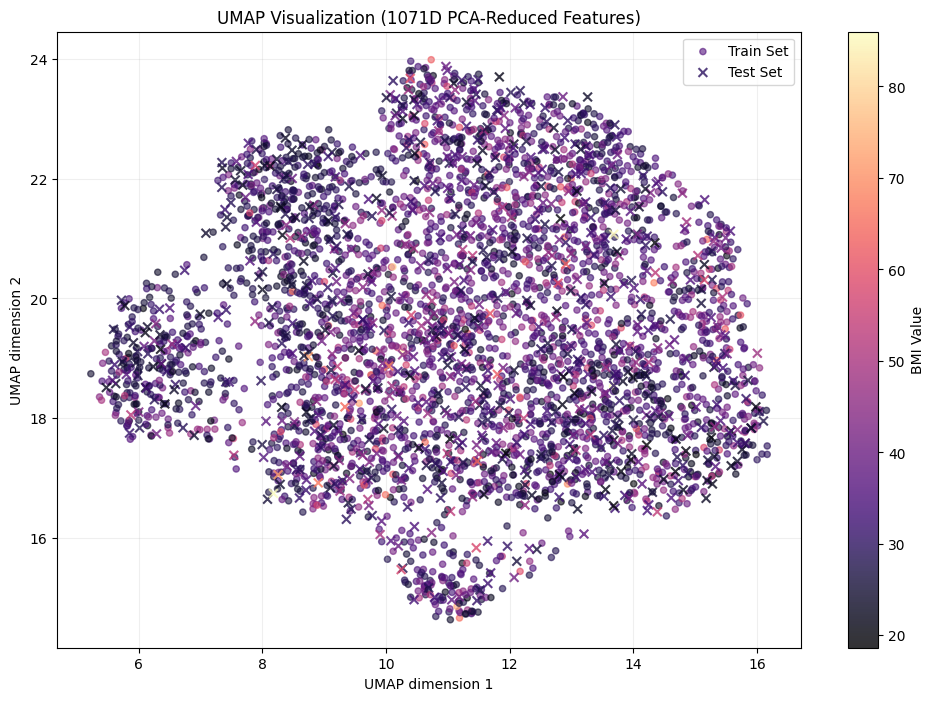

✅ UMAP (1071D) visualization completed.


In [22]:
# Cell 5: UMAP Visualization
try:
    import umap
except ImportError:
    !pip install umap-learn
    import umap

import matplotlib.pyplot as plt

print(f"🚀 Running UMAP on 1071D features (N={len(X_combined_pca)})...")

# 1. Initialize UMAP
# n_neighbors: balances local vs global structure (higher = more global)
# min_dist: how tightly points are packed together (lower = tighter)
reducer = umap.UMAP(
    n_neighbors=50, #15, 50
    min_dist=0.5, #0.1, 0.5
    n_components=2,
    metric='cosine', #cosine, euclidean
    random_state=42
)

# 2. Fit and Transform
X_umap_1071 = reducer.fit_transform(X_combined_pca)

# 3. Visualization
plt.figure(figsize=(12, 8))

# Scatter plot for Training Set (Circles)
plt.scatter(
    X_umap_1071[split_labels == 0, 0],
    X_umap_1071[split_labels == 0, 1],
    c=y_combined_bmi[split_labels == 0],
    cmap='magma',
    marker='o',
    alpha=0.6,
    label='Train Set',
    s=20
)

# Scatter plot for Testing Set (Crosses)
plt.scatter(
    X_umap_1071[split_labels == 1, 0],
    X_umap_1071[split_labels == 1, 1],
    c=y_combined_bmi[split_labels == 1],
    cmap='magma',
    marker='x',
    alpha=0.8,
    label='Test Set',
    s=40
)

plt.colorbar(label='BMI Value')
plt.title("UMAP Visualization (1071D PCA-Reduced Features)")
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print("✅ UMAP (1071D) visualization completed.")

## Cell 5.5: UMAP Visualization (4096D Raw Features)
In this cell, we bypass the linear PCA step and apply **UMAP** directly to the original **4096-dimensional** feature space. The goal is to verify if the non-linear manifold structure of the raw VGG-Face activations contains BMI-related patterns that were potentially suppressed or flattened during the 95% variance PCA compression.

We maintain the same `magma` color mapping and marker styles for direct comparison with previous experiments.

🚀 Running UMAP on RAW 4096D features (N=3962)...
Note: This may take a few minutes due to the high dimensionality.


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


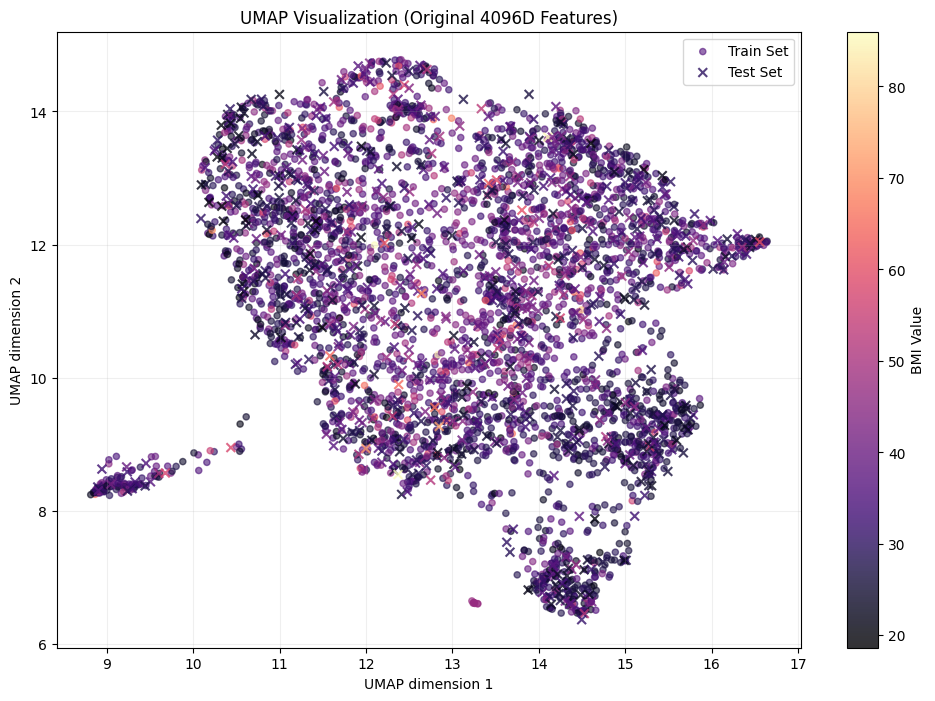

✅ UMAP (4096D) raw visualization completed.


In [23]:
# Cell 5.5: UMAP on Raw 4096D Features
import umap
import matplotlib.pyplot as plt

# 1. Prepare combined raw scaled data (4096D)
X_combined_raw = np.vstack([X_train_scaled, X_test_scaled])
# y_combined_bmi and split_labels remain the same as previous cells

print(f"🚀 Running UMAP on RAW 4096D features (N={len(X_combined_raw)})...")
print("Note: This may take a few minutes due to the high dimensionality.")

# 2. Initialize UMAP with standard parameters for raw data
reducer_4096 = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

# 3. Fit and Transform
X_umap_4096 = reducer_4096.fit_transform(X_combined_raw)

# 4. Visualization
plt.figure(figsize=(12, 8))

# Training Set
plt.scatter(
    X_umap_4096[split_labels == 0, 0],
    X_umap_4096[split_labels == 0, 1],
    c=y_combined_bmi[split_labels == 0],
    cmap='magma',
    marker='o',
    alpha=0.6,
    label='Train Set',
    s=20
)

# Testing Set
plt.scatter(
    X_umap_4096[split_labels == 1, 0],
    X_umap_4096[split_labels == 1, 1],
    c=y_combined_bmi[split_labels == 1],
    cmap='magma',
    marker='x',
    alpha=0.8,
    label='Test Set',
    s=40
)

plt.colorbar(label='BMI Value')
plt.title("UMAP Visualization (Original 4096D Features)")
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print("✅ UMAP (4096D) raw visualization completed.")

In [24]:
import joblib
import os

# Define the final output directory for hand-off
HANDOFF_DIR = os.path.join(W2_EXP_DIR, "handoff_v2")
os.makedirs(HANDOFF_DIR, exist_ok=True)

print(f"📦 Starting final packaging at: {HANDOFF_DIR}")

# --- 1. Export Labels and Metadata ---
np.save(os.path.join(HANDOFF_DIR, 'y_train_bmi.npy'), train_bmis)
np.save(os.path.join(HANDOFF_DIR, 'y_test_bmi.npy'), test_bmis)
np.save(os.path.join(HANDOFF_DIR, 'filenames_train.npy'), train_filenames)
np.save(os.path.join(HANDOFF_DIR, 'filenames_test.npy'), test_filenames)

# --- 2. Export 4096D Raw Scaled Features (For DL) ---
np.save(os.path.join(HANDOFF_DIR, 'X_train_4096d.npy'), X_train_scaled)
np.save(os.path.join(HANDOFF_DIR, 'X_test_4096d.npy'), X_test_scaled)

# --- 3. Export 1071D PCA Features (For SVR/XGB) ---
np.save(os.path.join(HANDOFF_DIR, 'X_train_1071d_pca95.npy'), X_train_pca)
np.save(os.path.join(HANDOFF_DIR, 'X_test_1071d_pca95.npy'), X_test_pca)

# --- 4. Export Transformation Models (For Inference) ---
# current_scaler comes from Cell 2.5; pca_95 comes from Cell 3
joblib.dump(current_scaler, os.path.join(HANDOFF_DIR, 'feature_scaler.pkl'))
joblib.dump(pca_95, os.path.join(HANDOFF_DIR, 'pca_95_model.pkl'))

print("\n✅ Hand-off package successfully generated!")
print(f"Total Files Saved: {len(os.listdir(HANDOFF_DIR))}")

📦 Starting final packaging at: /content/drive/MyDrive/ML2-Team2/Final Project/face-to-bmi/models/ryan/week2_experiments/handoff_v2

✅ Hand-off package successfully generated!
Total Files Saved: 10


### 📢 Week 2 Feature Architect Hand-off Report

**Target Auditor:** Role 4 (Modeling & Optimization)
**Data Version:** v2 (Standardized + FC6)

#### 📝 Dataset Summary:
* **Training Samples:** 3,210
* **Testing Samples:** 752
* **Original Dim:** 4096 (VGG-Face fc6)
* **PCA-95% Dim:** 1,071

#### ⚠️ Critical Engineering Notes:
1.  **Scaling**: All features are pre-scaled using `MaxAbsScaler`. Sparsity (66.08%) is preserved. DO NOT re-scale unless using a non-linear kernel that requires different normalization.
2.  **PCA Version**: The 1071D version is recommended for SVR baseline to handle the 'Curse of Dimensionality'.
3.  **Outliers**: A small isolated cluster was observed in UMAP/t-SNE. These samples are kept for now—please monitor if they cause high loss during training.
4.  **Consistency**: Use the provided `.pkl` files for any future data projection to maintain feature alignment.

## 📁 Week 2 Handoff: Feature Engineering to Modeling

**Author:** Ryan (Role 3 - Feature Architect)
**Status:** Completed & Verified
**Target Path:** `/models/ryan/week2_experiments/handoff_v2/`

---

### 1. Data Package Overview
I have finalized and "frozen" the features extracted from the **VGG-Face (fc6 layer)**. All samples are strictly aligned with the cleaned dataset from Week 1.

**Contents of `handoff_v2`:**
* `X_train_4096d.npy` / `X_test_4096d.npy`: **Raw Scaled Features.** (Best for MLP/Deep Learning).
* `X_train_1071d_pca95.npy` / `X_test_1071d_pca95.npy`: **PCA-Reduced Features.** (Captures 95% variance; recommended for SVR/XGBoost).
* `y_train_bmi.npy` / `y_test_bmi.npy`: **BMI Labels** (Targets).
* `filenames_train.npy` / `filenames_test.npy`: Original image filenames for reference.
* `feature_scaler.pkl`: The `MaxAbsScaler` object used for normalization.
* `pca_95_model.pkl`: The trained PCA model.

---

### 2. Quick Start for Role 4 (Modeling)
To start training, simply load the `.npy` files directly into your notebook:

```python
import numpy as np
import os

# Set your path
HANDOFF_DIR = '[Path_to_handoff_v2]'

# Load for SVR/Traditional ML
X_train = np.load(os.path.join(HANDOFF_DIR, 'X_train_1071d_pca95.npy'))
y_train = np.load(os.path.join(HANDOFF_DIR, 'y_train_bmi.npy'))

# Load for Deep Learning (MLP)
X_train_dl = np.load(os.path.join(HANDOFF_DIR, 'X_train_4096d.npy'))

```
---

### 3. Engineering Insights & Recommendations
* Preprocessing: All features are already scaled to [0, 1] while preserving sparsity (66.08%). Do not apply standard scaling unless necessary for specific kernels, as it may break the zero-value semantic meaning.

* The "Mystery Cluster": During UMAP visualization, a small isolated cluster was detected. If you encounter unexpected high loss on specific samples, we may need to investigate these outliers.

* Model Selection:
  * Use the 1071D set for SVR (RBF Kernel) or Random Forest to avoid the curse of dimensionality.
  * Use the 4096D set for MLP, but ensure you include Dropout layers to mitigate overfitting.